# Phase 4b — three sign architectures across the (hx, hz) plane

Relative energy error of the three sign-aware arms on the doubled semion,
graded against exact references (`results/diagnostics/signfid_*.json`,
`results/ed/ed_hc*_ds_*.json`). rel-err = |E_tail − E0|/|E0| with E_tail the
median of the last 20 training energies. Identical recipe everywhere: minSR,
lr 0.01, 350 steps, seed 0, 8192 samples. Only completed runs (`.mpack`
present) are shown; missing cells are grey (cnnqC runs still in the queue —
re-execute after the final fetch).

| arm | architecture |
|---|---|
| **cnnqB** | real trunk + QEC head (sign-framed Hamiltonian) |
| **cnnqC** | complex trunk + QEC head |
| **cnnqR** | real trunk + QEC head + tie-gated residual phase MLP |

Full numeric table incl. the ceiling columns (1−F_s, 1−F_plus): `python scripts/phase4b_summary.py`.

In [1]:
import os, sys, glob, re, pathlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# house plot style (shared with the toric-code-nqs repo)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
FIGDIR = "figures"

ROOT = pathlib.Path.cwd()
if ROOT.name == 'analysis':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from scripts.phase4b_summary import load_refs, tail_stats

ARMS = ['cnnqB', 'cnnqC', 'cnnqR']
ARM_LABEL = {'cnnqB': 'B: real trunk + head',
             'cnnqC': 'C: complex trunk + head',
             'cnnqR': 'R: real trunk + head + residual'}
ARM_COLOR = {'cnnqB': '#0072B2', 'cnnqC': '#E69F00', 'cnnqR': '#009E73'}  # Okabe-Ito

refs = load_refs()
pat = re.compile(r'G-equiv_1_hc(\d+x\d+)_ds_(?:h0|hx([\d.]+)_hz([\d.]+))_(\w+)\.json$')
rel = {}
for f in glob.glob('results/nqs/G-equiv_1_hc*_ds_*.json'):
    if not os.path.exists(f.replace('.json', '.mpack')):
        continue                       # completed runs only
    m = pat.search(os.path.basename(f))
    if not m or m.group(4) not in ARMS:
        continue
    key = (m.group(1), round(float(m.group(2) or 0), 6), round(float(m.group(3) or 0), 6))
    e0 = refs.get(key, {}).get('E0')
    if e0:
        E, V, _, _, _ = tail_stats(f)
        rel[key + (m.group(4),)] = abs(E - e0) / abs(e0)
print(f'{len(rel)} completed graded runs loaded')

89 completed graded runs loaded


Text(0.5, 1.06, 'DS 2x2 (19 qubits): relative energy error across the field plane')

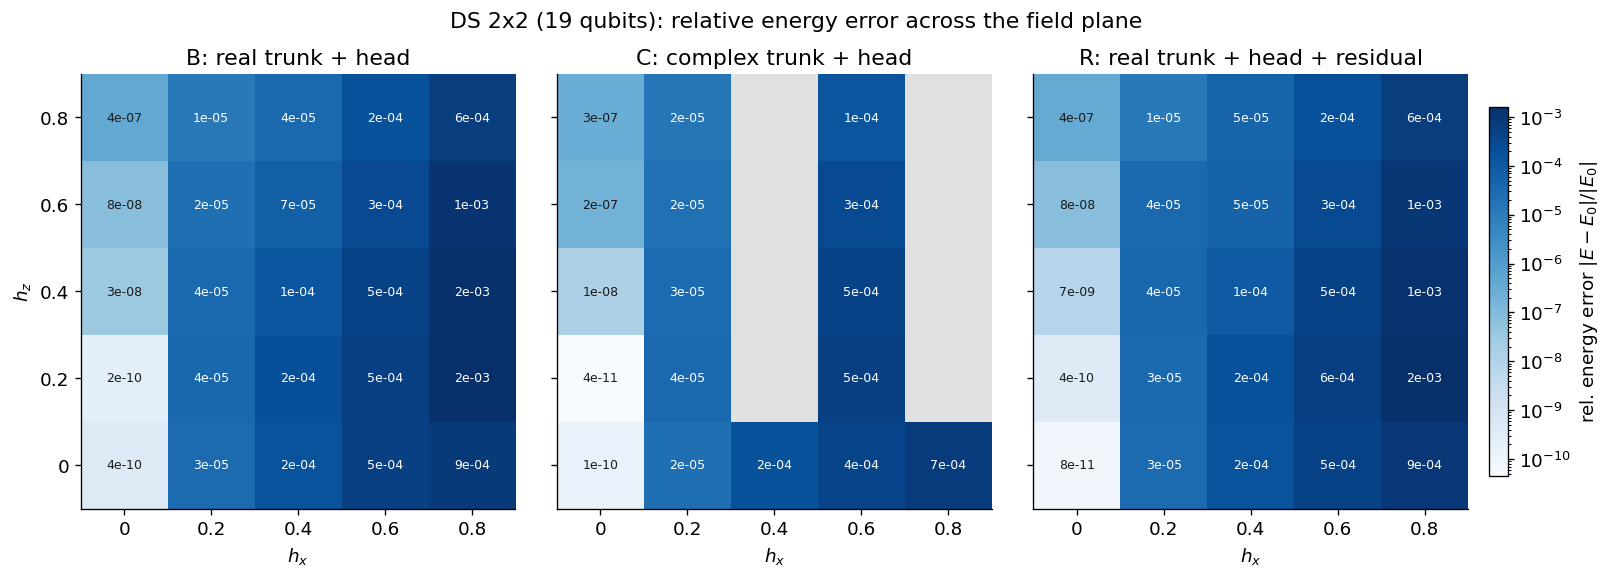

In [2]:
# 2x2: one heatmap per architecture, shared log color scale
VALS = [0.0, 0.2, 0.4, 0.6, 0.8]
grids = {arm: np.full((5, 5), np.nan) for arm in ARMS}
for arm in ARMS:
    for i, hz in enumerate(VALS):
        for j, hx in enumerate(VALS):
            grids[arm][i, j] = rel.get(('2x2', hx, hz, arm), np.nan)

allv = np.concatenate([g[np.isfinite(g)] for g in grids.values()])
norm = LogNorm(vmin=allv.min(), vmax=allv.max())
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharey=True, constrained_layout=True)
for ax, arm in zip(axes, ARMS):
    ax.grid(False)
    g = np.ma.masked_invalid(grids[arm])
    im = ax.imshow(g, origin='lower', cmap='Blues', norm=norm)
    ax.set_facecolor('0.88')                      # missing cells
    for i in range(5):
        for j in range(5):
            v = grids[arm][i, j]
            if np.isfinite(v):
                dark = norm(v) > 0.6
                ax.text(j, i, f'{v:.0e}', ha='center', va='center',
                        fontsize=7.5, color='white' if dark else '#1a1a1a')
    ax.set_xticks(range(5), [f'{v:g}' for v in VALS])
    ax.set_yticks(range(5), [f'{v:g}' for v in VALS])
    ax.set(xlabel='$h_x$', title=ARM_LABEL[arm])
axes[0].set(ylabel='$h_z$')
cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.015)
cb.set_label(r'rel. energy error $|E - E_0|/|E_0|$')
fig.suptitle('DS 2x2 (19 qubits): relative energy error across the field plane', y=1.06)
# fig.savefig(f"{FIGDIR}/phase4b_2x2_relerr.png", dpi=300, bbox_inches="tight")

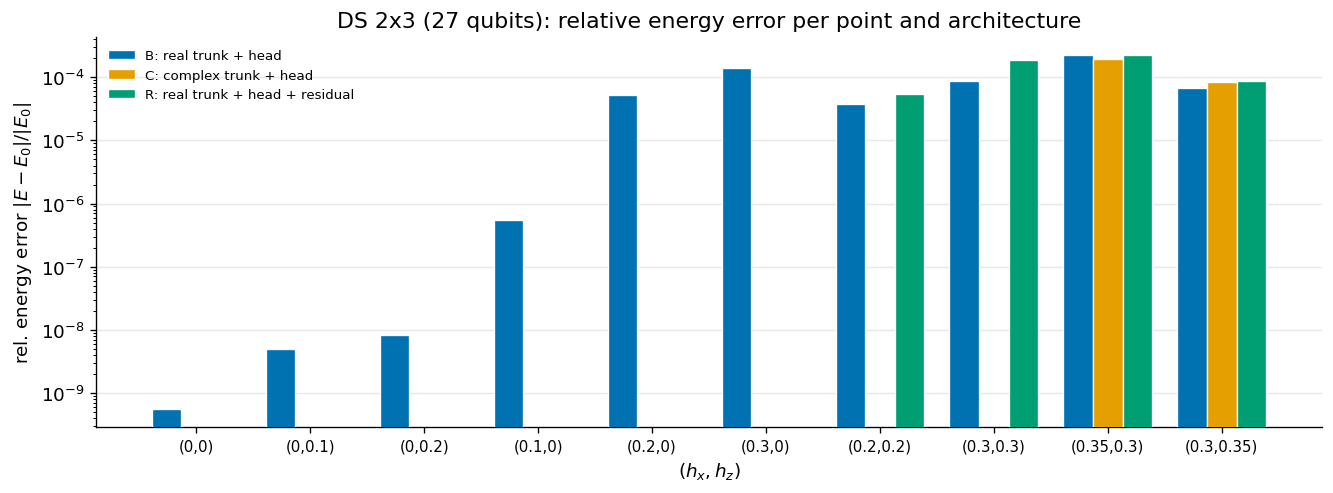

In [3]:
# 2x3 (27 qubits): all graded points, grouped bars per architecture
PTS = [(0.0, 0.0), (0.0, 0.1), (0.0, 0.2), (0.1, 0.0), (0.2, 0.0), (0.3, 0.0),
       (0.2, 0.2), (0.3, 0.3), (0.35, 0.3), (0.3, 0.35)]
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
w, x = 0.26, np.arange(len(PTS))
for k, arm in enumerate(ARMS):
    vals = [rel.get(('2x3', hx, hz, arm), np.nan) for hx, hz in PTS]
    ax.bar(x + (k - 1) * w, vals, w, color=ARM_COLOR[arm],
           label=ARM_LABEL[arm], edgecolor='white', linewidth=0.8, zorder=3)
ax.set_yscale('log')
ax.set_xticks(x, [f'({hx:g},{hz:g})' for hx, hz in PTS], fontsize=9)
ax.set(xlabel='$(h_x, h_z)$', ylabel=r'rel. energy error $|E - E_0|/|E_0|$',
       title='DS 2x3 (27 qubits): relative energy error per point and architecture')
ax.grid(axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=8, loc='upper left')
# fig.savefig(f"{FIGDIR}/phase4b_2x3_relerr.png", dpi=300, bbox_inches="tight")